<a href="https://colab.research.google.com/github/prachi2390/bank-marketing-decision-tree/blob/main/Traffic_Accident_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving traffic_accidents.csv to traffic_accidents.csv


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv('/content/traffic_accidents.csv')
df.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  object 
 1   traffic_control_device         209306 non-null  object 
 2   weather_condition              209306 non-null  object 
 3   lighting_condition             209306 non-null  object 
 4   first_crash_type               209306 non-null  object 
 5   trafficway_type                209306 non-null  object 
 6   alignment                      209306 non-null  object 
 7   roadway_surface_cond           209306 non-null  object 
 8   road_defect                    209306 non-null  object 
 9   crash_type                     209306 non-null  object 
 10  intersection_related_i         209306 non-null  object 
 11  damage                         209306 non-null  object 
 12  prim_contributory_cause       

,num_units,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
count,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000
mean,2.063300,0.382717,0.001859,0.038102,0.221241,0.121516,2.244002,13.373047,4.144024,6.771822
std,0.396012,0.799720,0.047502,0.233964,0.614960,0.450865,1.241175,5.603830,1.966864,3.427593
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,9.000000,2.000000,4.000000
50%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,14.000000,4.000000,7.000000
75%,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,17.000000,6.000000,10.000000
max,11.000000,21.000000,3.000000,7.000000,21.000000,15.000000,49.000000,23.000000,7.000000,12.000000


In [6]:
df.isnull().sum().sort_values(ascending=False)

,0
crash_date,0
traffic_control_device,0
weather_condition,0
lighting_condition,0
first_crash_type,0
trafficway_type,0
alignment,0
roadway_surface_cond,0
road_defect,0
crash_type,0


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

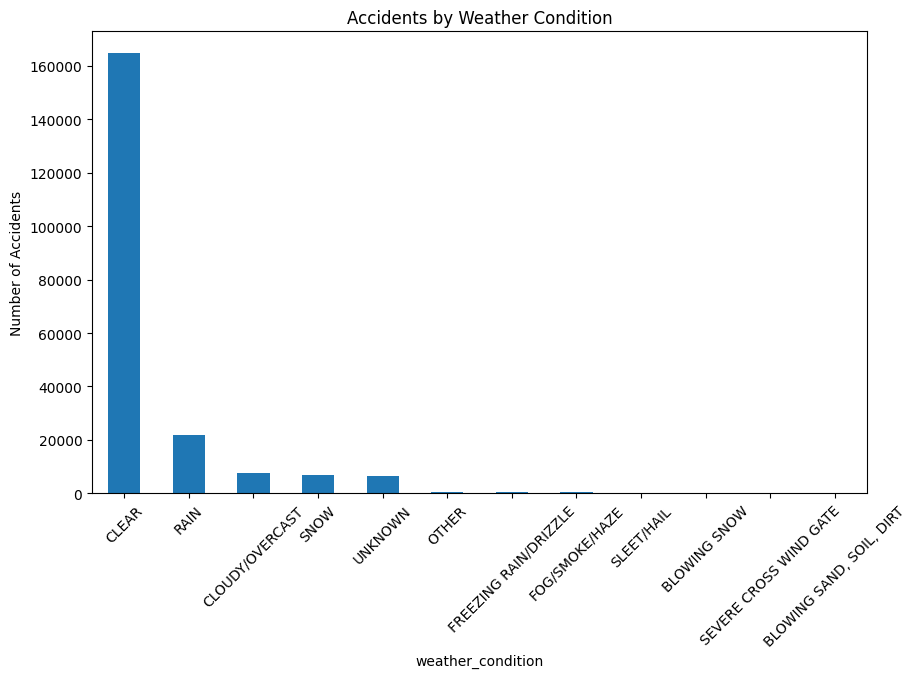

In [10]:
weather = df['weather_condition'].value_counts()

plt.figure(figsize=(10,6))
weather.plot(kind='bar')
plt.title("Accidents by Weather Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

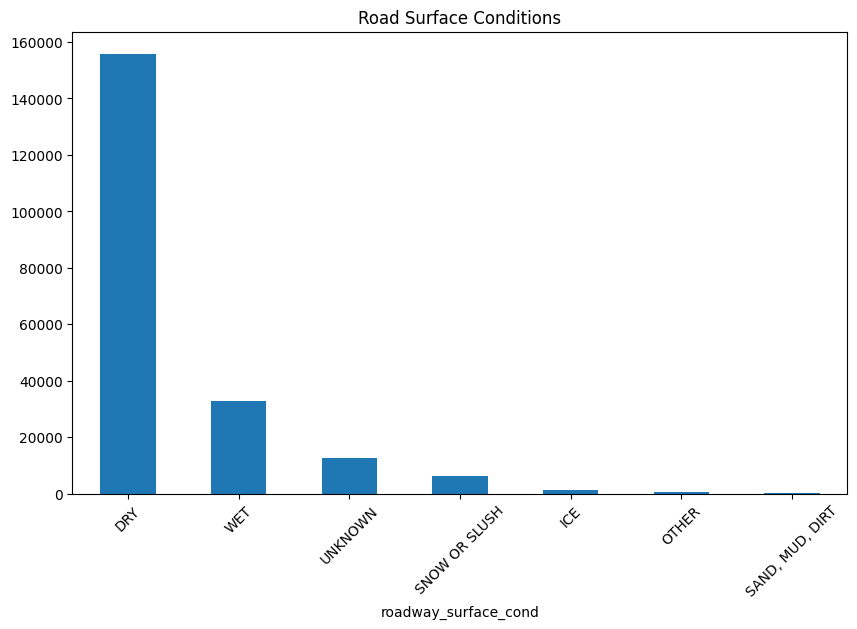

In [11]:
road = df['roadway_surface_cond'].value_counts()

plt.figure(figsize=(10,6))
road.plot(kind='bar')
plt.title("Road Surface Conditions")
plt.xticks(rotation=45)
plt.show()

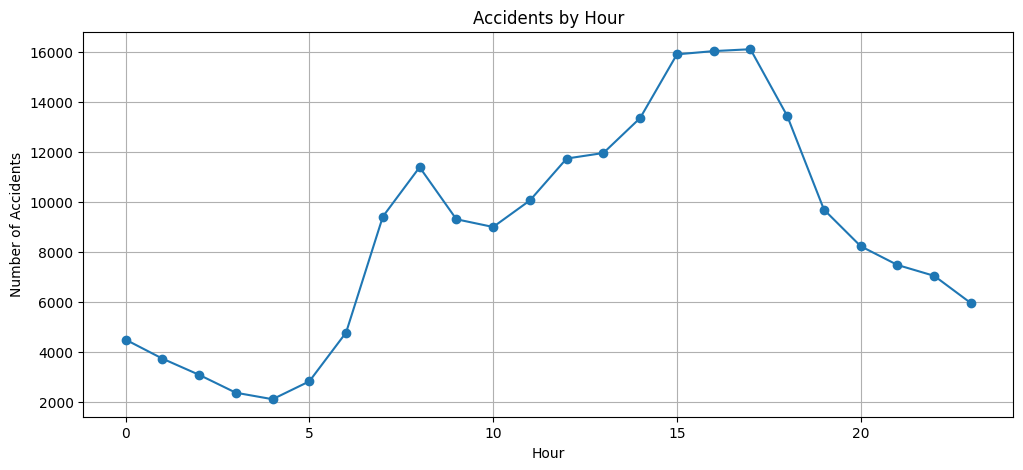

In [12]:
hourly = df['crash_hour'].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(hourly.index, hourly.values, marker='o')
plt.title("Accidents by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.grid()
plt.show()

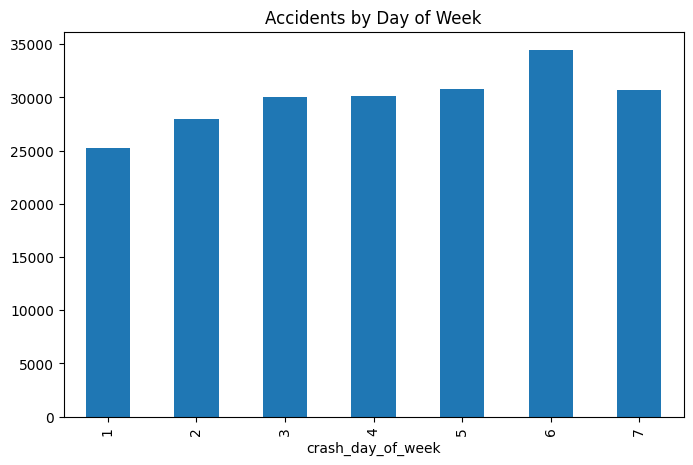

In [13]:
days = df['crash_day_of_week'].value_counts().sort_index()

plt.figure(figsize=(8,5))
days.plot(kind='bar')
plt.title("Accidents by Day of Week")
plt.show()

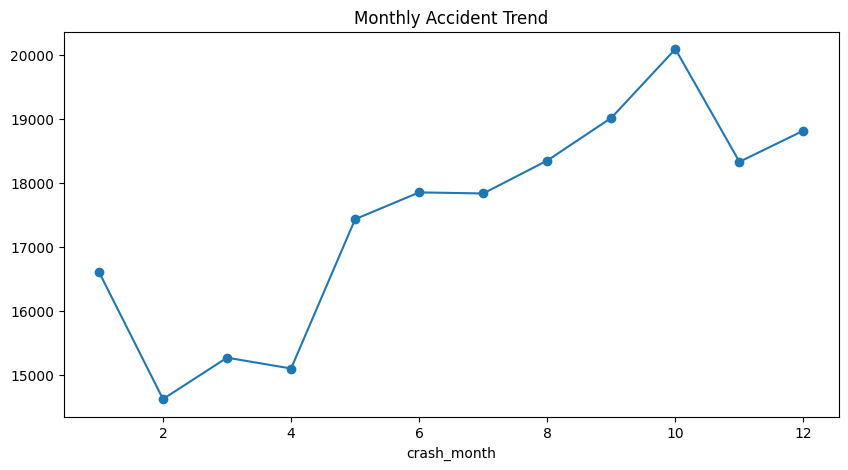

In [14]:
monthly = df['crash_month'].value_counts().sort_index()

plt.figure(figsize=(10,5))
monthly.plot(kind='line', marker='o')
plt.title("Monthly Accident Trend")
plt.show()

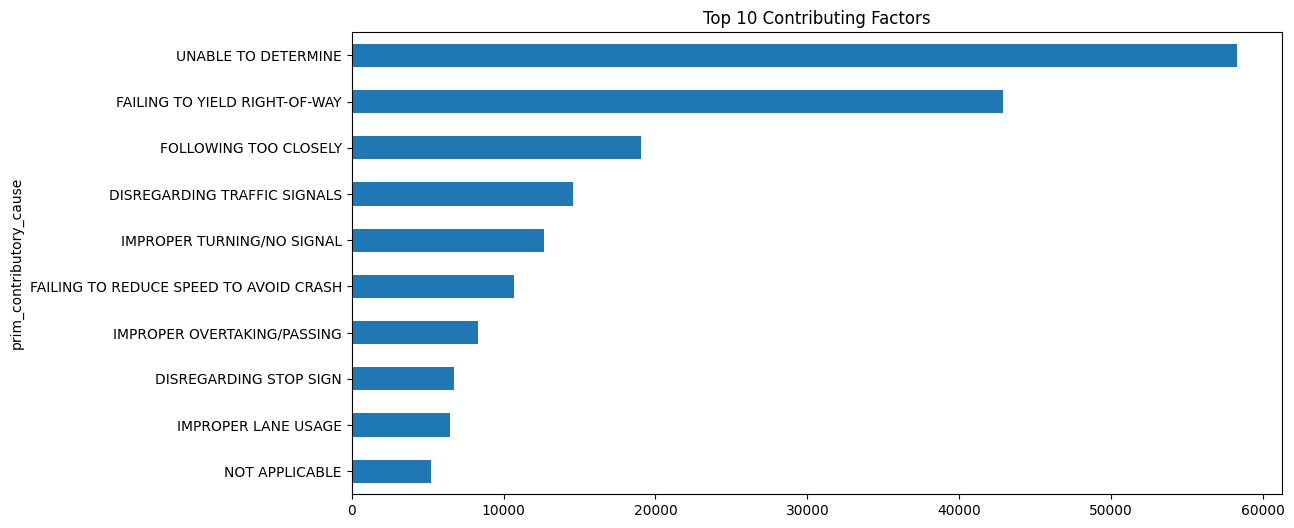

In [15]:
cause = df['prim_contributory_cause'].value_counts().head(10)

plt.figure(figsize=(12,6))
cause.sort_values().plot(kind='barh')
plt.title("Top 10 Contributing Factors")
plt.show()

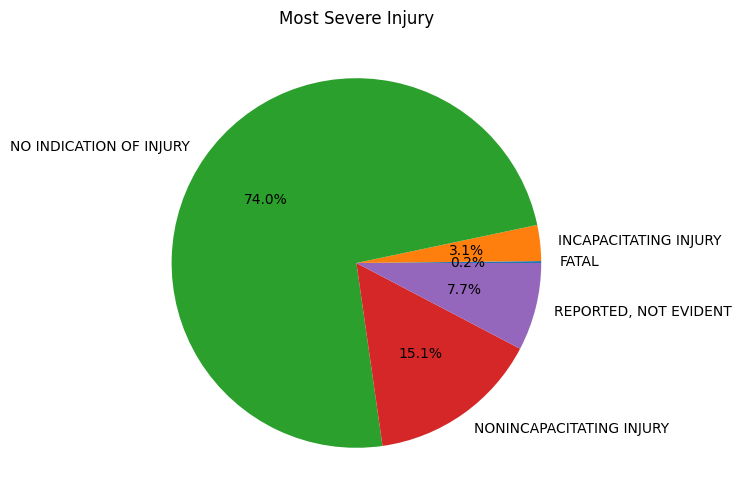

In [16]:
injury = df.groupby('most_severe_injury').size()

plt.figure(figsize=(8,6))
injury.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel("")
plt.title("Most Severe Injury")
plt.show()

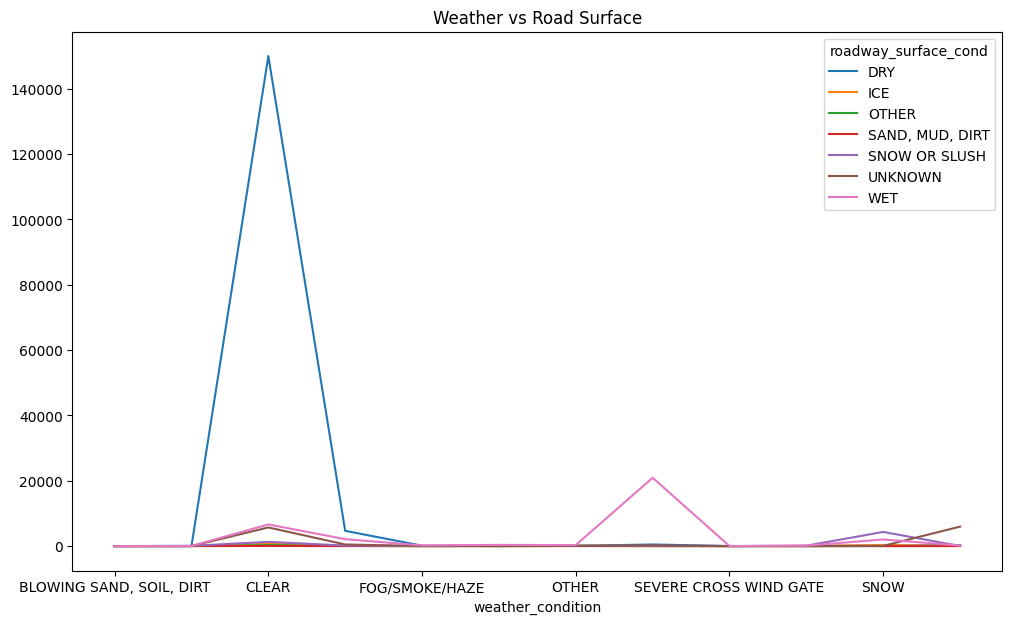

In [17]:
cross = pd.crosstab(df['weather_condition'],
                    df['roadway_surface_cond'])

cross.plot(figsize=(12,7))
plt.title("Weather vs Road Surface")
plt.show()

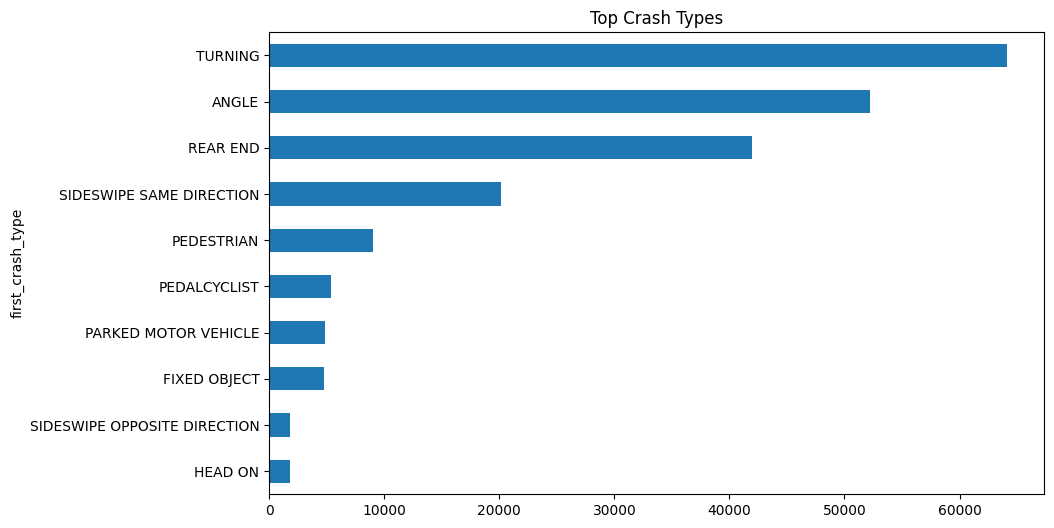

In [18]:
crash = df['first_crash_type'].value_counts().head(10)

plt.figure(figsize=(10,6))
crash.sort_values().plot(kind='barh')
plt.title("Top Crash Types")
plt.show()

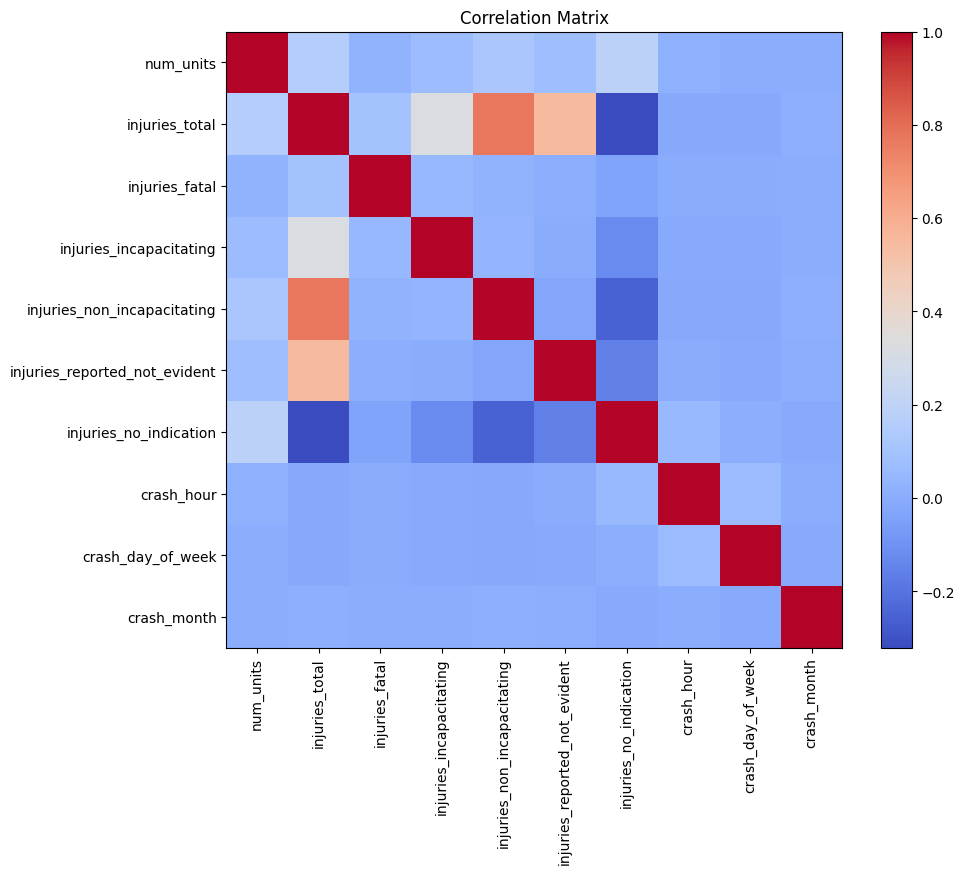

In [19]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

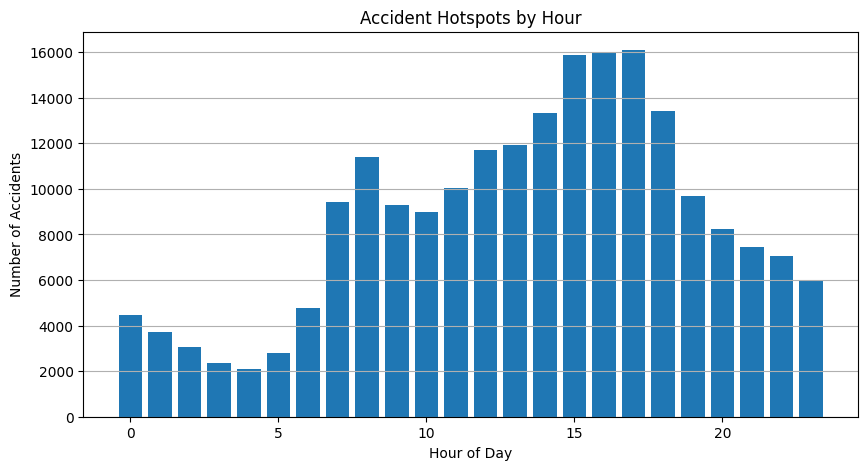

In [23]:
hourly = df['crash_hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(hourly.index, hourly.values)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.title("Accident Hotspots by Hour")
plt.grid(axis='y')
plt.show()